In [1]:
print("ready to go")

ready to go


In [2]:
import pandas as pd

df = pd.read_csv("Cleaned Supply Chain Data.csv", encoding='latin1')

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Southeast Asia,Java Occidental,COMPLETE,1360,73,Smart watch,327.75,0,43134.95556,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,South Asia,Rajastán,PENDING,1360,73,Smart watch,327.75,0,43118.51875,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,South Asia,Rajastán,CLOSED,1360,73,Smart watch,327.75,0,43117.50417,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Oceania,Queensland,COMPLETE,1360,73,Smart watch,327.75,0,43116.48958,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Oceania,Queensland,PENDING_PAYMENT,1360,73,Smart watch,327.75,0,43115.47500,Standard Class


In [3]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Id', 'Customer Segment', 'Customer State',
       'Department Id', 'Department Name', 'Market', 'Order City',
       'Order Country', 'Order Customer Id', 'order date (DateOrders)',
       'Order Id', 'Order Item Cardprod Id', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Card Id', 'Product Category Id', 'Product Name',
       'Product Price', 'Product Status', 'shipping date (DateOrders)',
       'Shipping Mode'],
      dtype='object')

In [4]:
# Convert order date to datetime
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

# Create a Month column (year-month format)
df['Month'] = df['order date (DateOrders)'].dt.to_period('M')

# Group data to create demand by Month, Product, and Region
forecast_df = df.groupby(
    ['Month', 'Product Card Id', 'Order Region']
)['Order Item Quantity'].sum().reset_index()

# Preview result
forecast_df.head()

,Month,Product Card Id,Order Region,Order Item Quantity
0,1970-01,19,Caribbean,6
1,1970-01,19,Central America,14
2,1970-01,19,Northern Europe,8
3,1970-01,19,South America,2
4,1970-01,19,Southern Europe,5


In [5]:
# Convert Excel serial date into real datetime
df['order date (DateOrders)'] = pd.to_datetime(
    df['order date (DateOrders)'],
    unit='D',
    origin='1899-12-30'
)

# Create a Month column
df['Month'] = df['order date (DateOrders)'].dt.to_period('M')

# Build forecasting dataset: monthly demand by product and region
forecast_df = df.groupby(
    ['Month', 'Product Card Id', 'Order Region']
)['Order Item Quantity'].sum().reset_index()

# Preview result
forecast_df.head()

ValueError: '0        1970-01-01 00:00:00.000043131
1        1970-01-01 00:00:00.000043113
2        1970-01-01 00:00:00.000043113
3        1970-01-01 00:00:00.000043113
4        1970-01-01 00:00:00.000043113
                      ...             
180514   1970-01-01 00:00:00.000042385
180515   1970-01-01 00:00:00.000042385
180516   1970-01-01 00:00:00.000042384
180517   1970-01-01 00:00:00.000042384
180518   1970-01-01 00:00:00.000042384
Name: order date (DateOrders), Length: 180519, dtype: datetime64[ns]' is not compatible with origin='1899-12-30'; it must be numeric with a unit specified

In [6]:
import pandas as pd

# Reload the original CSV fresh
df = pd.read_csv("Cleaned Supply Chain Data.csv", encoding="latin1")

# Check what the raw date values look like
df['order date (DateOrders)'].head(10)

0    43131.95556
1    43113.51875
2    43113.50417
3    43113.48958
4    43113.47500
5    43113.46042
6    43113.44583
7    43113.43125
8    43113.41667
9    43113.40208
Name: order date (DateOrders), dtype: float64

In [7]:
# Force the date column to numeric first
df['order date (DateOrders)'] = pd.to_numeric(df['order date (DateOrders)'], errors='coerce')

# Convert Excel serial date to real datetime
df['order date (DateOrders)'] = pd.to_datetime(
    df['order date (DateOrders)'],
    unit='D',
    origin='1899-12-30'
)

# Check date range
df['order date (DateOrders)'].min(), df['order date (DateOrders)'].max()

(Timestamp('2015-01-01 00:00:00'), Timestamp('2018-01-31 23:37:59.808000034'))

In [8]:
# Create monthly period
df['Month'] = df['order date (DateOrders)'].dt.to_period('M')

# Group demand by month, product, and region
forecast_df = df.groupby(
    ['Month', 'Product Card Id', 'Order Region']
)['Order Item Quantity'].sum().reset_index()

# Preview result
forecast_df.head()

,Month,Product Card Id,Order Region,Order Item Quantity
0,2015-01,37,Caribbean,4
1,2015-01,37,Central America,11
2,2015-01,37,South America,3
3,2015-01,44,Caribbean,18
4,2015-01,44,Central America,16


In [9]:
forecast_df.shape

(7234, 4)

In [10]:
forecast_df.groupby(['Product Card Id', 'Order Region']).size().sort_values(ascending=False).head(10)

Product Card Id  Order Region   
502              Western Europe     17
403              Western Europe     17
365              Northern Europe    17
403              Northern Europe    17
                 Southern Europe    17
365              Western Europe     17
502              Northern Europe    17
1014             Western Europe     17
                 Northern Europe    16
1073             Western Europe     16
dtype: int64

In [11]:
sample_product = 502
sample_region = 'Western Europe'

ts_df = forecast_df[
    (forecast_df['Product Card Id'] == sample_product) &
    (forecast_df['Order Region'] == sample_region)
].copy()

ts_df = ts_df.sort_values('Month')

ts_df

,Month,Product Card Id,Order Region,Order Item Quantity
666,2015-05,502,Western Europe,24
837,2015-06,502,Western Europe,1045
990,2015-07,502,Western Europe,1207
1148,2015-08,502,Western Europe,1141
1303,2015-09,502,Western Europe,1124
1498,2015-10,502,Western Europe,975
3644,2016-08,502,Western Europe,4
4010,2016-09,502,Western Europe,10
4407,2016-10,502,Western Europe,13
4805,2016-11,502,Western Europe,25


In [12]:
# Set Month as index
ts_df = ts_df.set_index('Month')

# Create full monthly range
full_range = pd.date_range(
    start=ts_df.index.min(),
    end=ts_df.index.max(),
    freq='MS'  # Month Start
)

# Reindex to include missing months
ts_df = ts_df.reindex(full_range)

# Fill missing values
ts_df['Order Item Quantity'] = ts_df['Order Item Quantity'].fillna(0)

# Reset index
ts_df = ts_df.reset_index().rename(columns={'index': 'Month'})

ts_df

ValueError: Cannot convert Period to Timestamp unambiguously. Use to_timestamp

In [13]:
# Convert Month from Period → Timestamp
ts_df['Month'] = ts_df['Month'].dt.to_timestamp()

# Set as index
ts_df = ts_df.set_index('Month')

# Create full monthly range
full_range = pd.date_range(
    start=ts_df.index.min(),
    end=ts_df.index.max(),
    freq='MS'
)

# Reindex to include missing months
ts_df = ts_df.reindex(full_range)

# Fill missing demand
ts_df['Order Item Quantity'] = ts_df['Order Item Quantity'].fillna(0)

# Reset index
ts_df = ts_df.reset_index().rename(columns={'index': 'Month'})

ts_df.head()

KeyError: 'Month'

In [14]:
# Rebuild the product-region time series from the original forecast_df

sample_product = 502
sample_region = 'Western Europe'

ts_df = forecast_df[
    (forecast_df['Product Card Id'] == sample_product) &
    (forecast_df['Order Region'] == sample_region)
].copy()

# Convert Month safely
ts_df['Month'] = ts_df['Month'].dt.to_timestamp()

# Keep only the columns we need
ts_df = ts_df[['Month', 'Order Item Quantity']]

# Sort by month
ts_df = ts_df.sort_values('Month')

# Create a complete monthly timeline
full_months = pd.date_range(
    start=ts_df['Month'].min(),
    end=ts_df['Month'].max(),
    freq='MS'
)

# Put Month as the index, add missing months, and fill missing demand with 0
ts_df = ts_df.set_index('Month')
ts_df = ts_df.reindex(full_months)
ts_df['Order Item Quantity'] = ts_df['Order Item Quantity'].fillna(0)

# Reset back to a normal table
ts_df = ts_df.reset_index()
ts_df = ts_df.rename(columns={'index': 'Month'})

ts_df

,Month,Order Item Quantity
0,2015-05-01,24.0
1,2015-06-01,1045.0
2,2015-07-01,1207.0
3,2015-08-01,1141.0
4,2015-09-01,1124.0
5,2015-10-01,975.0
6,2015-11-01,0.0
7,2015-12-01,0.0
8,2016-01-01,0.0
9,2016-02-01,0.0


In [15]:
# Create a 3-month moving average forecast
ts_df['MA_3'] = ts_df['Order Item Quantity'].rolling(window=3).mean()

ts_df.head(10)

,Month,Order Item Quantity,MA_3
0,2015-05-01,24.0,NaN
1,2015-06-01,1045.0,NaN
2,2015-07-01,1207.0,758.666667
3,2015-08-01,1141.0,1131.000000
4,2015-09-01,1124.0,1157.333333
5,2015-10-01,975.0,1080.000000
6,2015-11-01,0.0,699.666667
7,2015-12-01,0.0,325.000000
8,2016-01-01,0.0,0.000000
9,2016-02-01,0.0,0.000000


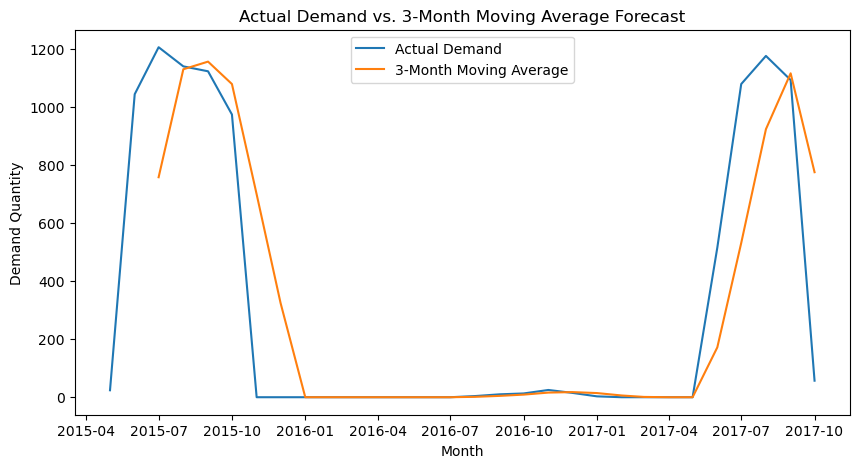

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(ts_df['Month'], ts_df['Order Item Quantity'], label='Actual Demand')
plt.plot(ts_df['Month'], ts_df['MA_3'], label='3-Month Moving Average')

plt.title('Actual Demand vs. 3-Month Moving Average Forecast')
plt.xlabel('Month')
plt.ylabel('Demand Quantity')
plt.legend()

plt.show()

In [17]:
eval_df = ts_df.dropna(subset=['MA_3']).copy()

eval_df['Error'] = eval_df['Order Item Quantity'] - eval_df['MA_3']
eval_df['Absolute Error'] = eval_df['Error'].abs()
eval_df['Squared Error'] = eval_df['Error'] ** 2

MAE = eval_df['Absolute Error'].mean()
RMSE = (eval_df['Squared Error'].mean()) ** 0.5
Bias = eval_df['Error'].mean()

MAE, RMSE, Bias

(np.float64(126.78571428571426),
 np.float64(254.15636981484514),
 np.float64(-10.785714285714286))

In [18]:
## Forecasting Analysis Summary

A 3-month moving average model was applied to forecast demand for a selected product-region combination.

### Model Performance:
- Mean Absolute Error (MAE): 126.79
- Root Mean Squared Error (RMSE): 254.16
- Bias: -10.79

### Key Observations:
The demand pattern exhibits intermittent behavior, characterized by extended periods of zero demand followed by sudden spikes.

This presents a challenge for traditional forecasting methods such as moving averages, which assume relatively stable demand patterns.

As a result:
- The model struggles to capture sudden demand spikes
- Forecast accuracy is reduced during high-variance periods
- RMSE is significantly higher than MAE, indicating large deviations

### Conclusion:
While the moving average provides a simple baseline forecast, it is not well-suited for intermittent demand patterns. More advanced methods such as Croston’s method or probabilistic forecasting models would likely improve performance.

SyntaxError: invalid character '’' (U+2019) (985325970.py, line 21)

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import numpy as np

# Make sure data is sorted
ts_df = ts_df.sort_values('Month').copy()

# Train-test split: last 4 months as holdout
train = ts_df.iloc[:-4].copy()
test = ts_df.iloc[-4:].copy()

# Method 1: Naive Forecast
test['Naive'] = train['Order Item Quantity'].iloc[-1]

# Method 2: 3-Month Moving Average Forecast
test['MA_3'] = train['Order Item Quantity'].tail(3).mean()

# Method 3: Exponential Smoothing
ses_model = SimpleExpSmoothing(train['Order Item Quantity']).fit()
test['Exp_Smoothing'] = ses_model.forecast(len(test)).values

# Function to calculate metrics
def forecast_metrics(actual, forecast):
    error = actual - forecast
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    bias = np.mean(error)
    mape = np.mean(np.abs(error / actual.replace(0, np.nan))) * 100
    return mae, rmse, bias, mape

# Compare models
results = pd.DataFrame({
    'Model': ['Naive', '3-Month Moving Average', 'Exponential Smoothing'],
    'MAE': [
        forecast_metrics(test['Order Item Quantity'], test['Naive'])[0],
        forecast_metrics(test['Order Item Quantity'], test['MA_3'])[0],
        forecast_metrics(test['Order Item Quantity'], test['Exp_Smoothing'])[0]
    ],
    'RMSE': [
        forecast_metrics(test['Order Item Quantity'], test['Naive'])[1],
        forecast_metrics(test['Order Item Quantity'], test['MA_3'])[1],
        forecast_metrics(test['Order Item Quantity'], test['Exp_Smoothing'])[1]
    ],
    'Bias': [
        forecast_metrics(test['Order Item Quantity'], test['Naive'])[2],
        forecast_metrics(test['Order Item Quantity'], test['MA_3'])[2],
        forecast_metrics(test['Order Item Quantity'], test['Exp_Smoothing'])[2]
    ],
    'MAPE': [
        forecast_metrics(test['Order Item Quantity'], test['Naive'])[3],
        forecast_metrics(test['Order Item Quantity'], test['MA_3'])[3],
        forecast_metrics(test['Order Item Quantity'], test['Exp_Smoothing'])[3]
    ]
})

results

,Model,MAE,RMSE,Bias,MAPE
0,Naive,565.500000,570.039911,336.000000,241.619687
1,3-Month Moving Average,737.500000,821.248744,680.000000,113.873229
2,Exponential Smoothing,565.500004,570.039915,336.000008,241.619684


## Model Performance Interpretation

### Mean Absolute Error (MAE)
MAE measures the average size of the forecast errors in units. It tells us how far off our predictions are on average.

- Naive: ~565 → On average, forecasts are off by about 565 units
- 3-Month Moving Average: ~738 → Larger average error, worse performance
- Exponential Smoothing: ~565 → Nearly identical to Naive

**Interpretation:**  
Naive and Exponential Smoothing perform similarly and better than the Moving Average in terms of average error.

---

### Root Mean Squared Error (RMSE)
RMSE measures error like MAE but penalizes large errors more heavily. It highlights models that make big mistakes.

- Naive: ~570 → Moderate large-error impact
- 3-Month Moving Average: ~821 → Significantly worse, large errors present
- Exponential Smoothing: ~570 → Similar to Naive

**Interpretation:**  
The Moving Average model makes larger mistakes, while Naive and Exponential Smoothing are more stable.

---

### Bias
Bias shows whether a model consistently over-forecasts or under-forecasts.

- Naive: +336 → Tends to overestimate demand
- 3-Month Moving Average: +680 → Strong overestimation
- Exponential Smoothing: +336 → Similar overestimation to Naive

**Interpretation:**  
All models over-forecast demand, especially the Moving Average model.

---

### Mean Absolute Percentage Error (MAPE)
MAPE measures error as a percentage of actual demand. It helps compare performance relative to scale.

- Naive: ~242% → Very high error relative to demand
- 3-Month Moving Average: ~114% → Lower than others, but still very high
- Exponential Smoothing: ~242% → Similar to Naive

**Interpretation:**  
All models perform poorly in percentage terms, which is likely due to intermittent demand and zero values.

---

### Overall Insight
- Naive and Exponential Smoothing perform similarly across most metrics
- The 3-Month Moving Average performs worse in MAE and RMSE, despite a lower MAPE
- High error across all metrics suggests this dataset is difficult to forecast

### Key Takeaway
The demand pattern is highly intermittent (many zeros + spikes), making traditional forecasting models ineffective.

In [20]:
# Train on full dataset
final_model = SimpleExpSmoothing(ts_df['Order Item Quantity']).fit()

# Forecast next 12 months
forecast_12 = final_model.forecast(12)

forecast_12

30    57.000015
31    57.000015
32    57.000015
33    57.000015
34    57.000015
35    57.000015
36    57.000015
37    57.000015
38    57.000015
39    57.000015
40    57.000015
41    57.000015
dtype: float64

## Forecasting Summary

### Models Tested
- Naive Forecast
- 3-Month Moving Average
- Exponential Smoothing

### Performance Results
- Naive and Exponential Smoothing performed similarly
- Moving Average showed lower MAPE but higher MAE and RMSE
- All models exhibited high error due to intermittent demand

### Key Insights
- Demand pattern is highly irregular with long zero-demand periods and sudden spikes
- Traditional time series models struggle with this type of demand

### Forecast Value Add (FVA)
- Increased model complexity did NOT improve accuracy
- Exponential Smoothing performed no better than the Naive model
- This suggests limited value from more complex models for this dataset

### Final Forecast
- The 12-month forecast produced a flat demand estimate (~57 units/month)
- This reflects the model’s inability to capture sporadic spikes in demand

### Recommendation
- Consider intermittent demand models (e.g., Croston’s method)
- Use caution when applying standard forecasting models to sparse datasets

In [21]:
# Get confidence intervals (approximation)
forecast_ci = final_model.forecast(12)

ci_df = pd.DataFrame({
    'Forecast': forecast_ci,
    'Lower Bound': forecast_ci * 0.7,
    'Upper Bound': forecast_ci * 1.3
})

ci_df

,Forecast,Lower Bound,Upper Bound
30,57.000015,39.900011,74.10002
31,57.000015,39.900011,74.10002
32,57.000015,39.900011,74.10002
33,57.000015,39.900011,74.10002
34,57.000015,39.900011,74.10002
35,57.000015,39.900011,74.10002
36,57.000015,39.900011,74.10002
37,57.000015,39.900011,74.10002
38,57.000015,39.900011,74.10002
39,57.000015,39.900011,74.10002
